In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Refinement
Fonction qui va permettre de refine le topolical graphe initial, avec marge d'erreur de 2px

In [36]:
from skimage import io
from meta import ROOT_DIR
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from bez.topo_graph import extract_topology_from_skeleton, extract_simple_topology_from_skeleton, image_to_skeleton
from bez.refinement import  refine
from bez.hypergraph import HyperGraph, HyperEdge
from bez.global_optim import optimisation
from bez.viz import visualize_topo

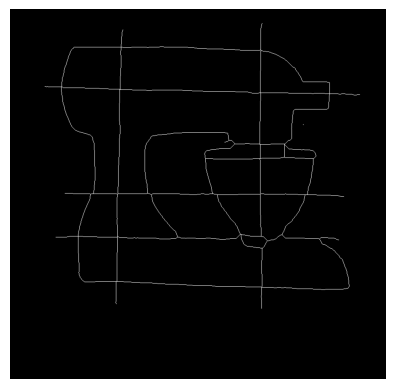

c:\Users\matgi\OneDrive\Documents\ecole_lycee\Telecom_Paris2024_2025\IGR\CSC_4IG08_TP\sketch-vectorization\.venv\lib\site-packages\networkx\drawing\nx_pylab.py:457: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


Text(0.5, 1.0, 'Topology (naive)')

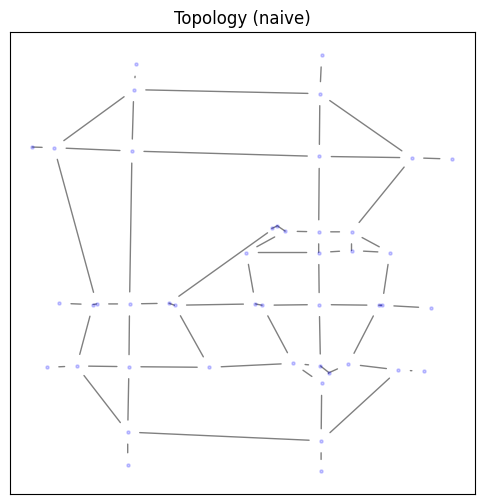

In [45]:
# Skeleton extraction
img = io.imread(ROOT_DIR /"data/original_paper/figure_2/input.png")#[100:250, 600:780, :]

skeletone, thikness = image_to_skeleton(img)
plt.imshow(skeletone, cmap="gray")
plt.axis("off")
plt.show()


topo_graph = extract_simple_topology_from_skeleton(skeletone)
topo_graph_ = extract_topology_from_skeleton(skeletone)


plt.figure(figsize=(6, 6))
visualize_topo(topo_graph, full_graph=True)
plt.title("Topology (naive)")




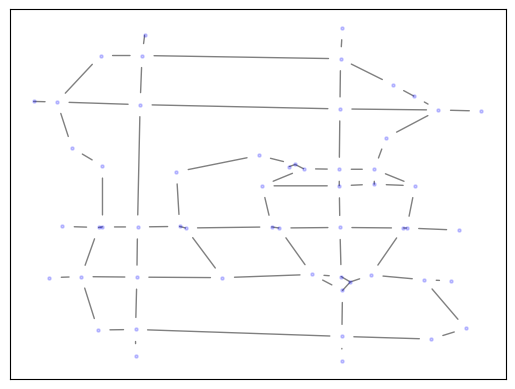

In [38]:
topo_graph = refine(topo_graph)
# visualize_subgraph(topo_graph, full_graph=True)
visualize_topo(topo_graph, full_graph=True)




In [39]:
hyper = HyperGraph(topo_graph)

# param
lam = 0.5
temp = 0.5
t_min = 0.05
mu = 0.3
t_decrease = 0.999 ** (1/len(topo_graph.nodes))

In [40]:
error = optimisation(hyper, lam=lam, mu=mu, temp=temp, t_decrease=t_decrease, t_min=t_min)


100%|██████████| 131181/131181 [00:47<00:00, 2785.74it/s]


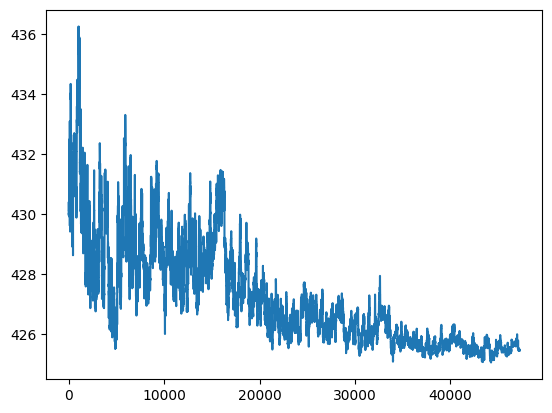

In [41]:
plt.plot(range(len(error)), error)

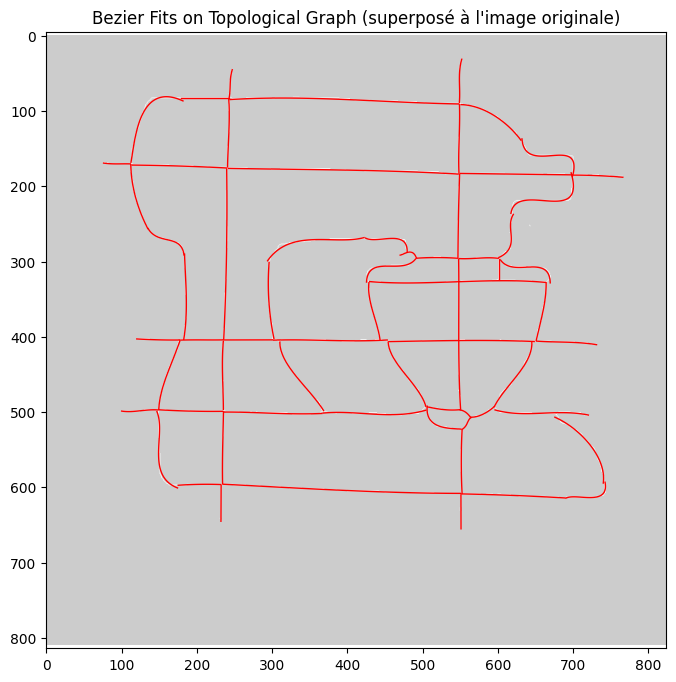

In [42]:
hyper.fit_beziers()

plt.figure(figsize=(8, 8))
# Superpose l'image originale

plt.imshow(skeletone, cmap="gray", alpha=0.2)
hyper.visualize_fiting()

plt.axis("equal")
plt.title("Bezier Fits on Topological Graph (superposé à l'image originale)")
plt.show()

In [43]:
hyper.smooth_bezier_junctions()

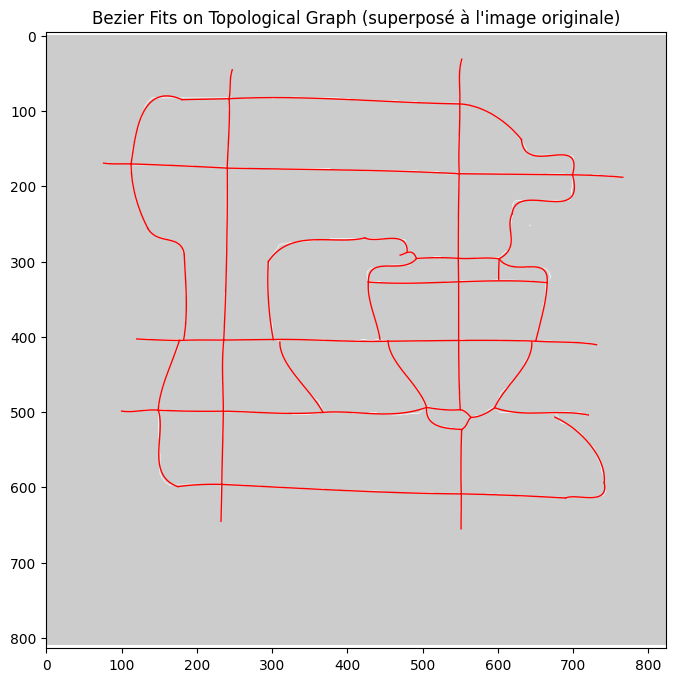

In [44]:

plt.figure(figsize=(8, 8))
# Superpose l'image originale

plt.imshow(skeletone, cmap="gray", alpha=0.2)
hyper.visualize_fiting()

plt.axis("equal")
plt.title("Bezier Fits on Topological Graph (superposé à l'image originale)")
plt.show()